# Trabajo Final: QLAB - Fundamentos de Programación en Python 2025

Integrantes:
- **Alfredo Ludmir Aro Terleira**
- **Romina Ariana Loayza Gaitán**

# Comisarias y denuncias de tránsito

## Paso 1: Agregamos nuestras bases de datos

### 1.1. Microdatos INEI: Censo Nacional de Comisarias 2017

#### 1.1.1. Capítulo 100: Infraestructura 

Variables:
- UBIGEO: Número de ubigeo
- NOMBREDI: Nombre del distrito
- INF115_INV_AT: ¿Cuántos policías realizan investigación de accidentes de tránsito? - Total

Observación: esta base de datos se encontraba en formato `spss`, por lo que tuvimos que transformarla a `csv`

In [624]:
import pandas as pd

locacion_1 = "C:/Users/USUARIO/Documents/GitHub/QLAB_PP_Trabajo_Final/Cap_100_Infraestructura_2017.csv"
c_infraestructura = pd.read_csv(locacion_1)
c_infraestructura.head()

,ID_N,UBIGEO,CCDI,NOMBREDI,INF109,INF109A,INF109A_O,INF109B1,INF109C1_D1,INF109C1_D2,...,INF126_10,INF126_11,INF126_12,INF126_13,INF126_14,INF126_15,INF126_16,INF126_O,GPSLATITUD_INF,GPSLONGITUD_INF
0,1,100601,1,RUPA-RUPA,De 40001 - 80000 Hab,Distrital,,,,,...,,,,,,,,,-9.298070,-76.002608
1,2,100606,6,MARIANO DAMASO BERAUN,De 5000 - 10000 Hab,Distrital,,,,,...,,,,,,,,,-9.494613,-75.953068
2,3,100604,4,JOSE CRESPO Y CASTILLO,De 20001 - 40000 Hab,Distrital,,,,,...,,,,,,,,,-8.931409,-76.111890
3,4,221001,1,TOCACHE,De 5000 - 10000 Hab,Provincial,,,,,...,,,,,,,,,-8.188440,-76.512271
4,5,221002,2,NUEVO PROGRESO,De 5000 - 10000 Hab,Distrital,,,,,...,,,,,,,,,-8.453412,-76.324172


In [625]:
len(c_infraestructura)

1495

In [626]:
variables1 = ["UBIGEO", "NOMBREDI", "INF115_INV_AT"]
c_infraestructura = c_infraestructura[variables1].copy()
c_infraestructura.head()

,UBIGEO,NOMBREDI,INF115_INV_AT
0,100601,RUPA-RUPA,6
1,100606,MARIANO DAMASO BERAUN,3
2,100604,JOSE CRESPO Y CASTILLO,2
3,221001,TOCACHE,3
4,221002,NUEVO PROGRESO,2


In [627]:
c_infraestructura.rename(columns={
    'UBIGEO': 'ubigeo',
    'NOMBREDI': 'distrito',
    'INF115_INV_AT': 'n_policias'
}, inplace=True)

In [628]:
c_infraestructura.columns

Index(['ubigeo', 'distrito', 'n_policias'], dtype='object')

Necesitamos agrupar los valores a nivel distrital para Lima Metropolitana y Callao:

In [630]:
c_infraestructura['ubigeo'].unique()

array([100601, 100606, 100604, ...,  80914,  50203,  30417], dtype=int64)

Ubigeo Lima y Callao:
- Lima: 150101-150143
- Callao: 70101-70107

In [632]:
# Filtrar las filas donde 'ubigeo' comienza con '1501' o '0701'
c_infraestructura['ubigeo'] = c_infraestructura['ubigeo'].astype(str)
c_infraestructura = c_infraestructura[c_infraestructura['ubigeo'].str.startswith(('1501','701'))]
c_infraestructura['ubigeo'].unique()

array(['150101', '150102', '150103', '150104', '150105', '150106',
       '150107', '150108', '150109', '150110', '150111', '150115',
       '150112', '150128', '150113', '150114', '150116', '150117',
       '150118', '150143', '150119', '150120', '150121', '150122',
       '150123', '150124', '150125', '150126', '150127', '150129',
       '150130', '150131', '150132', '150133', '150134', '150135',
       '150136', '150137', '150138', '150139', '150140', '150141',
       '150142', '70101', '70102', '70103', '70104', '70105', '70107',
       '70106'], dtype=object)

In [633]:
c_infraestructura.dtypes

ubigeo        object
distrito      object
n_policias     int64
dtype: object

Agrupamos por distrito de Lima Metropolitana y Callao

In [635]:
c_infraestructura = c_infraestructura.groupby('distrito')['n_policias'].sum().reset_index()
print(c_infraestructura)

                      distrito  n_policias
0                        ANCON           2
1                          ATE          13
2                     BARRANCO           4
3                   BELLAVISTA           4
4                        BREÑA           7
5                       CALLAO          30
6                   CARABAYLLO           9
7   CARMEN DE LA LEGUA REYNOSO           2
8                   CHACLACAYO           2
9                   CHORRILLOS          17
10                 CIENEGUILLA           3
11                       COMAS          15
12                 EL AGUSTINO          11
13               INDEPENDENCIA           9
14                 JESUS MARIA           5
15                   LA MOLINA          11
16                    LA PERLA           2
17                    LA PUNTA           1
18                 LA VICTORIA          11
19                        LIMA          28
20                       LINCE           4
21                  LOS OLIVOS          14
22         

#### 1.1.2. Capítulo 300: Detalle - Infraestructura

Variables:
- UBIGEO: Ubigeo
- NOMBREDI: Nombre del distrito
- INF308_1: Total de equipos informáticos

Observación: esta base de datos se encontraba en formato `spss`, por lo que tuvimos que transformarla a `csv`

In [637]:
locacion_2 = "C:/Users/USUARIO/Documents/GitHub/QLAB_PP_Trabajo_Final/Cap_300_Equipamiento_2017.csv"
c_infraestructura_2 = pd.read_csv(locacion_2)
c_infraestructura_2.head()

,ID_N,UBIGEO,CCDI,NOMBREDI,INF301,INF301_TOTAL,INF302_1,INF303_1,INF304A_1,INF304B_1,...,INF352_6_8,INF352_7_8,INF352_8_8,INF352_9_8,INF352_10_8,INF352_11_8,INF352_12_8,INF352_13_8,INF352_13_8_O,INF352_14_8
0,1,10,1,RUPA-RUPA,Sí,3,Sí,3,3,0,...,,,,,,,,,,
1,2,10,6,MARIANO DAMASO BERAUN,No,,No,,,,...,,,,,,,,,,
2,3,10,4,JOSE CRESPO Y CASTILLO,No,,No,,,,...,,,,,,,,,,
3,4,22,1,TOCACHE,Sí,1,Sí,1,1,0,...,,,,,,,,,,
4,5,22,2,NUEVO PROGRESO,No,,No,,,,...,,,,,,,,,,


In [638]:
variables2 = ["UBIGEO","NOMBREDI", "INF308_1"]
c_infraestructura_2 = c_infraestructura_2[variables2].copy()
c_infraestructura_2.head()

,UBIGEO,NOMBREDI,INF308_1
0,10,RUPA-RUPA,13
1,10,MARIANO DAMASO BERAUN,3
2,10,JOSE CRESPO Y CASTILLO,5
3,22,TOCACHE,7
4,22,NUEVO PROGRESO,4


In [639]:
c_infraestructura_2.rename(columns={
    'UBIGEO': 'ubigeo',
    'NOMBREDI': 'distrito',
    'INF308_1': 'total_equipos_infor'
}, inplace=True)

c_infraestructura_2.columns

Index(['ubigeo', 'distrito', 'total_equipos_infor'], dtype='object')

Filtramos los distritos de Lima Metropolitana y Callao:

In [641]:
# Filtrar las filas donde 'ubigeo' comienza con '1501' o '0701'
c_infraestructura_2['ubigeo'] = c_infraestructura_2['ubigeo'].astype(str)
c_infraestructura_2 = c_infraestructura_2[c_infraestructura_2['ubigeo'].str.startswith(('15','7'))]
c_infraestructura_2['ubigeo'].unique()

array(['15', '7'], dtype=object)

In [642]:
c_infraestructura_2['distrito'].unique()

array(['LIMA', 'ANCON', 'ATE', 'BARRANCO', 'BREÑA', 'CARABAYLLO',
       'CHACLACAYO', 'CHORRILLOS', 'CIENEGUILLA', 'COMAS', 'EL AGUSTINO',
       'LA VICTORIA', 'INDEPENDENCIA', 'RIMAC', 'JESUS MARIA',
       'LA MOLINA', 'LINCE', 'LOS OLIVOS', 'LURIGANCHO',
       'VILLA MARIA DEL TRIUNFO', 'LURIN', 'MAGDALENA DEL MAR',
       'PUEBLO LIBRE', 'MIRAFLORES', 'PACHACAMAC', 'PUCUSANA',
       'PUENTE PIEDRA', 'PUNTA HERMOSA', 'PUNTA NEGRA', 'SAN BARTOLO',
       'SAN BORJA', 'SAN ISIDRO', 'SAN JUAN DE LURIGANCHO',
       'SAN JUAN DE MIRAFLORES', 'SAN LUIS', 'SAN MARTIN DE PORRES',
       'SAN MIGUEL', 'SANTA ANITA', 'SANTA MARIA DEL MAR', 'SANTA ROSA',
       'SANTIAGO DE SURCO', 'SURQUILLO', 'VILLA EL SALVADOR', 'BARRANCA',
       'PARAMONGA', 'PATIVILCA', 'SUPE', 'SUPE PUERTO', 'CANTA',
       'SANTA ROSA DE QUIVES', 'SAN VICENTE DE CAÑETE', 'ASIA', 'CALANGO',
       'CERRO AZUL', 'CHILCA', 'IMPERIAL', 'LUNAHUANA', 'MALA',
       'NUEVO IMPERIAL', 'PACARAN', 'QUILMANA', 'SAN ANTONIO',

In [643]:
c_infraestructura_2.dtypes

ubigeo                 object
distrito               object
total_equipos_infor    object
dtype: object

In [644]:
#Convertimos la variable total_equipos_infor a int
c_infraestructura_2['total_equipos_infor'] = pd.to_numeric(c_infraestructura_2['total_equipos_infor'], errors='coerce')
c_infraestructura_2.dtypes

ubigeo                 object
distrito               object
total_equipos_infor     int64
dtype: object

Agrupamos por distritos de Lima Metropolitana y Callao:

In [646]:
c_infraestructura_2 = c_infraestructura_2.groupby('distrito')['total_equipos_infor'].sum().reset_index()
print(c_infraestructura_2)

                   distrito  total_equipos_infor
0                   ALLAUCA                    4
1                     AMBAR                    5
2                     ANCON                   12
3                      ASIA                   10
4                       ATE                   67
..                      ...                  ...
91               VENTANILLA                   70
92        VILLA EL SALVADOR                   69
93  VILLA MARIA DEL TRIUNFO                   77
94                   YAUYOS                   13
95                   ZUÑIGA                    7

[96 rows x 2 columns]


#### 1.1.3. Capítulo 100: AT

Variables:
- UBIGEO: Ubigeo
- NOMBREDI: Nombre del distrito
- AT_TOT: Número total de accidentes de tránsito

Observación: esta base de datos se encontraba en formato `spss`, por lo que tuvimos que transformarla a `csv`

In [648]:
locacion_3 = "C:/Users/USUARIO/Documents/GitHub/QLAB_PP_Trabajo_Final/A_T_Capitulo_100.csv"
c_accidentes = pd.read_csv(locacion_3)
c_accidentes.head()

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_23216\2651577351.py:2: DtypeWarning: Columns (97,98) have mixed types. Specify dtype option on import or set low_memory=False.
  c_accidentes = pd.read_csv(locacion_3)


,ID_N,UBIGEO,CCDI,NOMBREDI,ANIO,ID_AT,AT_N,AT_NALF,AT_TOT,AT101,...,AT109_13,AT109_14,AT109_15,AT109_16,AT109_17,AT109_18,AT109_19,AT109_19_O,Factor_2016,Factor_2017
0,1,100601,1,RUPA-RUPA,2016,1,,,75,Libro de ocurrencias de tránsito comunes,...,0,0,0,0,0,0,0,,2.253333,
1,1,100601,1,RUPA-RUPA,2016,2,,,75,Libro de ocurrencias de tránsito comunes,...,0,0,0,0,0,0,0,,2.253333,
2,1,100601,1,RUPA-RUPA,2016,3,,,75,Libro de ocurrencias de tránsito comunes,...,0,0,0,0,0,0,0,,2.253333,
3,1,100601,1,RUPA-RUPA,2016,4,,,75,Libro de ocurrencias de tránsito comunes,...,0,0,0,0,0,0,0,,2.253333,
4,1,100601,1,RUPA-RUPA,2016,5,,,75,Libro de ocurrencias de tránsito comunes,...,0,0,0,0,0,0,0,,2.253333,


In [649]:
len(c_accidentes)

68811

In [650]:
variables3 = ["UBIGEO", "NOMBREDI", "AT_TOT"]
c_accidentes = c_accidentes[variables3].copy()
c_accidentes.head()

,UBIGEO,NOMBREDI,AT_TOT
0,100601,RUPA-RUPA,75
1,100601,RUPA-RUPA,75
2,100601,RUPA-RUPA,75
3,100601,RUPA-RUPA,75
4,100601,RUPA-RUPA,75


In [651]:
c_accidentes.rename(columns={
    'UBIGEO': 'ubigeo',
    'NOMBREDI': 'distrito',
    'AT_TOT': 'n_denuncias'
}, inplace=True)

In [652]:
c_accidentes.columns

Index(['ubigeo', 'distrito', 'n_denuncias'], dtype='object')

Filtrados los distritos de Lima Metropolitana y Callao

In [654]:
c_accidentes['ubigeo'] = c_accidentes['ubigeo'].astype(str)
c_accidentes = c_accidentes[c_accidentes['ubigeo'].str.startswith(('1501','701'))]
c_accidentes['ubigeo'].unique()

array(['150101', '150102', '150103', '150104', '150105', '150106',
       '150107', '150108', '150109', '150110', '150111', '150115',
       '150112', '150128', '150113', '150114', '150116', '150117',
       '150118', '150143', '150119', '150120', '150121', '150122',
       '150123', '150124', '150125', '150126', '150127', '150129',
       '150130', '150131', '150132', '150133', '150134', '150135',
       '150136', '150137', '150138', '150139', '150140', '150141',
       '150142', '70101', '70102', '70103', '70104', '70105', '70107',
       '70106'], dtype=object)

In [655]:
c_accidentes.tail()

,ubigeo,distrito,n_denuncias
68804,70101,CALLAO,21
68805,70101,CALLAO,21
68806,70101,CALLAO,21
68807,70101,CALLAO,21
68808,70101,CALLAO,21


En este caso vemos que las filas se multiplican, así que solo nos quedamos con una por cada distrito según el ubigeo:

In [657]:
c_accidentes = c_accidentes.drop_duplicates(subset='ubigeo')
c_accidentes.head()

,ubigeo,distrito,n_denuncias
9416,150101,LIMA,75
10127,150102,ANCON,75
10202,150103,ATE,75
10527,150104,BARRANCO,75
10602,150105,BREÑA,75


## Paso 2: Merge

In [659]:
data_final = c_accidentes.merge(c_infraestructura, on='distrito', how='inner').merge(c_infraestructura_2, on='distrito', how='inner')
data_final.head()

,ubigeo,distrito,n_denuncias,n_policias,total_equipos_infor
0,150101,LIMA,75,28,216
1,150102,ANCON,75,2,12
2,150103,ATE,75,13,67
3,150104,BARRANCO,75,4,21
4,150105,BREÑA,75,7,41


In [690]:
data_final.shape

(50, 5)

## Paso 3: Gráficos

### 3.1. Ordered bar 1

In [696]:
import altair as alt

grafico1 = alt.Chart(data_final).mark_bar(color='green').encode(
    x=alt.X('n_denuncias:Q', title='Número de denuncias'),  
    y=alt.Y('distrito', title='Distrito'),  
).properties(
    title='Número de denuncias de tránsito por distrito'  
)

grafico1.show()

alt.Chart(...)

### 3.2. Ordered bar 2

In [ ]:
grafico2 = alt.Chart(data_final).mark_bar(color='red').encode(
    x=alt.X('total_equipos_infor:Q', title='Número de equipos informáticos'),  
    y=alt.Y('distrito', title='Distrito'),  
).properties(
    title='Número de equipos informáticos por distrito'  
)

grafico2.show()

### 3.3. Mapa de calor de correlaciones

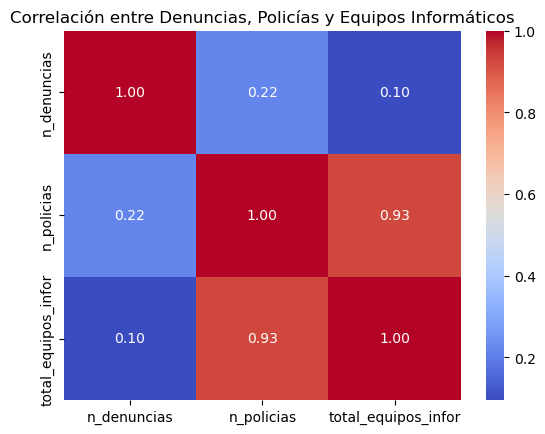

In [720]:
import matplotlib.pyplot as plt
import seaborn as sns 

corr = data_final[['n_denuncias', 'n_policias', 'total_equipos_infor']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlación entre Denuncias, Policías y Equipos Informáticos')
plt.show()